<a href="https://colab.research.google.com/github/malik8-beep/Hello/blob/main/FANAF_INSURANCE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Cellule 1: Installation et Imports
!pip install plotly -q  # Pour graphs interactifs

import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from statsmodels.stats.outliers_influence import variance_inflation_factor
from patsy import dmatrices
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson
from statsmodels.tsa.stattools import adfuller
from statsmodels.iolib.summary2 import summary_col

In [2]:
# Cellule 2: Chargement des Données (uploadez Dataset_Digit.xlsx dans Colab)
df = pd.read_excel('/content/drive/MyDrive/FANAF/Dataset_Digit.xlsx')  # Ou utilisez files.upload() si besoin


In [3]:
# Nettoyage amélioré
df['Taux_PN'] = df['Taux_PN'].str.replace('%', '').astype(float) / 100
df['Inflation'] = df['Inflation'].str.replace('%', '').astype(float) / 100

In [4]:
# Imputation NaN par médiane par pays (mieux que dropna pour panel court)

# Convert Taux_AB and Taux_UT to numeric before imputation
for col_to_convert in ['Taux_AB', 'Taux_UT']:
    df[col_to_convert] = pd.to_numeric(df[col_to_convert], errors='coerce')

for col in ['Taux_AB', 'Taux_UT']:
    df[col] = df.groupby('Pays')[col].transform(lambda x: x.fillna(x.median()))

df = df.dropna()  # Drop restant si nécessaire
df['log_PIB'] = np.log(df['PIB'])
df['Taux_PN_L1'] = df.groupby('Pays')['Taux_PN'].shift(1)
df = df.dropna(subset=['Taux_PN_L1'])  # Perte première année par pays

print(df.head())
print(f"Shape: {df.shape} | Pays uniques: {df['Pays'].nunique()}")

           Pays  Année  Primes_Brutes      PIB  Taux_PN  Taux_AB  Taux_UT  \
1         Bénin   2020           66.0   8684.2   0.0076    100.0   75.499   
2         Bénin   2021           75.0   9740.3   0.0077    107.0   81.092   
3         Bénin   2022           84.1  10256.1   0.0082    113.0   82.141   
4         Bénin   2023           98.3  11045.0   0.0089    116.0   82.970   
6  Burkina Faso   2020          107.8  13645.6   0.0079     97.0   70.107   

   Inflation   log_PIB  Taux_PN_L1  
1     0.0302  9.069261      0.0072  
2     0.0173  9.184027      0.0076  
3     0.0135  9.235628      0.0077  
4     0.0273  9.309733      0.0082  
6     0.0188  9.521172      0.0073  
Shape: (30, 10) | Pays uniques: 8


In [5]:
# Cellule 3: Analyse Descriptive
# Stats descriptives
print(df.describe())

             Année  Primes_Brutes           PIB    Taux_PN     Taux_AB  \
count    30.000000      30.000000     30.000000  30.000000   30.000000   
mean   2021.500000     163.064000  15391.753333   0.008703  107.033333   
std       1.106408     193.711488  12948.437812   0.003911   31.560815   
min    2020.000000       1.550000   1324.900000   0.001200   58.000000   
25%    2021.000000      52.475000   8377.975000   0.005500   81.250000   
50%    2021.500000      76.600000  11185.300000   0.008250  107.000000   
75%    2022.000000     186.900000  17214.975000   0.012425  120.500000   
max    2023.000000     734.900000  53253.600000   0.014200  172.000000   

         Taux_UT  Inflation    log_PIB  Taux_PN_L1  
count  30.000000  30.000000  30.000000   30.000000  
mean   54.402333   0.041747   9.335069    0.008487  
std    25.624719   0.031521   0.840788    0.003803  
min     3.246000   0.004400   7.189092    0.001000  
25%    40.231750   0.021800   9.033142    0.005575  
50%    61.61900

In [6]:
# Boxplot Taux_PN par pays
fig = px.box(df, x='Pays', y='Taux_PN', title='Distribution Pénétration Assurance par Pays')
fig.show()

In [7]:
# Trends temporels
fig = px.line(df, x='Année', y='Taux_PN', color='Pays', title='Évolution Pénétration Assurance')
fig.show()

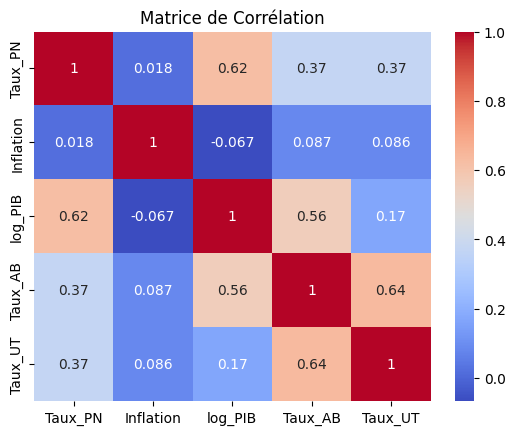

In [8]:
# Heatmap corrélation
corr = df[['Taux_PN', 'Inflation', 'log_PIB', 'Taux_AB', 'Taux_UT']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Matrice de Corrélation')
plt.show()

In [9]:
# Cellule 4: Tests Préliminaires
# VIF (multicolinéarité)
formula = 'Taux_PN ~ Taux_PN_L1 + Inflation + log_PIB + Taux_AB + Taux_UT'
y, X = dmatrices(formula, df, return_type='dataframe')
vif = pd.DataFrame()
vif['Variable'] = X.columns
vif['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print(vif)

     Variable         VIF
0   Intercept  232.588360
1  Taux_PN_L1    2.006058
2   Inflation    1.032765
3     log_PIB    2.751152
4     Taux_AB    2.866975
5     Taux_UT    2.209407


In [10]:
# Stationnarité (ADF test par pays pour Taux_PN)
for pays, group in df.groupby('Pays'):
    if len(group['Taux_PN']) > 1:
        if group['Taux_PN'].nunique() > 1: # Check if there is variation
            adf = adfuller(group['Taux_PN'])
            print(f"{pays}: ADF Stat = {adf[0]:.4f}, p-value = {adf[1]:.4f}")
        else:
            print(f"{pays}: Taux_PN est constant, ADF test non applicable.")
    else:
        print(f"{pays}: Pas assez de données pour l'ADF test.")

Burkina Faso: ADF Stat = -4.0415, p-value = 0.0012
Bénin: ADF Stat = 1.6038, p-value = 0.9979
Côte d'Ivoire: ADF Stat = -0.0000, p-value = 0.9585
Guinée Bissau: Taux_PN est constant, ADF test non applicable.
Mali: ADF Stat = -3.5796, p-value = 0.0062
Niger: ADF Stat = 0.0000, p-value = 0.9585
Sénégal: ADF Stat = 1.5396, p-value = 0.9977
Togo: ADF Stat = -0.0340, p-value = 0.9556


In [11]:
# Cellule 5: Modélisation
# Pooled OLS
pooled = smf.ols(formula, df).fit(cov_type='HC3')

In [12]:
# Fixed Effects (pays + année)
fe_formula = 'Taux_PN ~ Taux_PN_L1 + Inflation + log_PIB + Taux_AB + Taux_UT + C(Pays) + C(Année)'
fe = smf.ols(fe_formula, df).fit(cov_type='HC3')

In [13]:
# Random Effects
re = smf.mixedlm('Taux_PN ~ Taux_PN_L1 + Inflation + log_PIB + Taux_AB + Taux_UT', df, groups='Pays').fit()

/usr/local/lib/python3.12/dist-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning:

The MLE may be on the boundary of the parameter space.



In [14]:
# Cellule 5: Modélisation
# Pooled OLS
pooled = smf.ols(formula, df).fit(cov_type='HC3')

# Fixed Effects (pays + année)
fe_formula = 'Taux_PN ~ Taux_PN_L1 + Inflation + log_PIB + Taux_AB + Taux_UT + C(Pays) + C(Année)'
fe = smf.ols(fe_formula, df).fit(cov_type='HC3')

# Random Effects
re = smf.mixedlm('Taux_PN ~ Taux_PN_L1 + Inflation + log_PIB + Taux_AB + Taux_UT', df, groups='Pays').fit()

# Hausman test (FE vs RE) - manuel approximatif

# It's crucial to compare only the coefficients of variables common to both models.
# The Fixed Effects model (fe) includes dummies for 'Pays' and 'Année', which the
# Random Effects model (re) does not explicitly estimate as fixed coefficients.
# We need to find the intersection of parameter names.
common_param_names = list(set(fe.params.index) & set(re.params.index))

# Filter the parameters for common variables
fe_params_common = fe.params[common_param_names]
re_params_common = re.params[common_param_names]

# Filter the covariance matrices for common variables
fe_cov_common = fe.cov_params().loc[common_param_names, common_param_names]
re_cov_common = re.cov_params().loc[common_param_names, common_param_names]

# Calculate the difference in coefficients
diff_params = fe_params_common - re_params_common

# Calculate the difference in covariance matrices
diff_cov = fe_cov_common - re_cov_common

# The original code attempted to use .diagonal() on a DataFrame, which is incorrect.
# Use np.diag() to extract the diagonal (variances) from the covariance difference matrix.
# This aligns with the simplified Hausman formula used in the original attempt.
hausman = (diff_params**2) / np.diag(diff_cov)

# Sum the components to get the overall Hausman test statistic
hausman_stat = hausman.sum()

# The degrees of freedom is the number of common parameters
df_hausman = len(common_param_names)

# Import scipy.stats for chi2 distribution
import scipy.stats as st

# Calculate p-value using the chi-squared CDF.
p_hausman = 1 - st.chi2.cdf(hausman_stat, df_hausman)

print(f"Hausman chi2: {hausman_stat:.2f}, p-value: {p_hausman:.4f}")

Hausman chi2: 7.93, p-value: 0.2430


/usr/local/lib/python3.12/dist-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning:

The MLE may be on the boundary of the parameter space.



In [15]:
# Tableau récapitulatif
table = summary_col([pooled, fe, re], stars=True, model_names=['Pooled OLS', 'Fixed Effects', 'Random Effects'])
print(table)


                         Pooled OLS Fixed Effects Random Effects
----------------------------------------------------------------
Intercept                -0.0002    0.0345        -0.0004       
                         (0.0010)   (0.0303)      (0.0013)      
Taux_PN_L1               1.0159***  0.6649        1.0081***     
                         (0.0288)   (0.5052)      (0.0375)      
Inflation                0.0012     -0.0025       0.0011        
                         (0.0030)   (0.0030)      (0.0019)      
log_PIB                  0.0000     -0.0039       0.0000        
                         (0.0001)   (0.0031)      (0.0002)      
Taux_AB                  -0.0000    0.0000        -0.0000       
                         (0.0000)   (0.0000)      (0.0000)      
Taux_UT                  0.0000     0.0000        0.0000        
                         (0.0000)   (0.0000)      (0.0000)      
C(Pays)[T.Bénin]                    -0.0023                     
                        

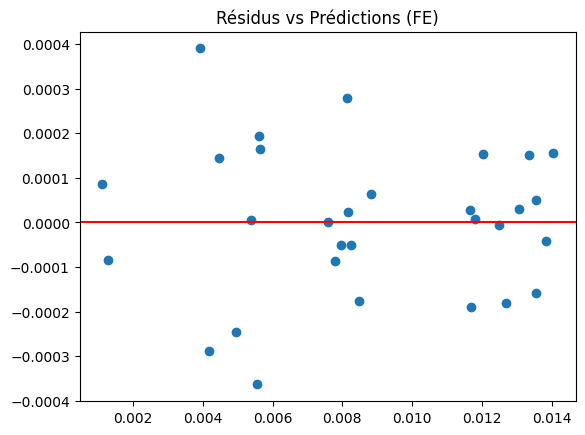

In [16]:
# Cellule 6: Diagnostics (sur FE)
# Résidus vs prédits
plt.scatter(fe.fittedvalues, fe.resid)
plt.axhline(0, color='red')
plt.title('Résidus vs Prédictions (FE)')
plt.show()

In [17]:
# Hétéroscédasticité (Breusch-Pagan)
bp_test = het_breuschpagan(fe.resid, fe.model.exog)
print(f"Breusch-Pagan LM: {bp_test[0]:.2f}, p-value: {bp_test[1]:.4f}")

Breusch-Pagan LM: 20.89, p-value: 0.1405


In [18]:
# Autocorrélation (Durbin-Watson)
dw = durbin_watson(fe.resid)
print(f"Durbin-Watson: {dw:.2f} (proche 2 = pas d'autocorrélation)")

Durbin-Watson: 2.26 (proche 2 = pas d'autocorrélation)


In [19]:
# Cellule 7: Robustesse et Extensions
# Sous-ensemble (e.g., sans petits pays)
df_large = df[~df['Pays'].isin(['Centrafrique', 'Guinée Bissau'])]
fe_large = smf.ols(fe_formula, df_large).fit(cov_type='HC3')
print(summary_col([fe, fe_large], stars=True, model_names=['FE Full', 'FE Large Countries']))


                         FE Full  FE Large Countries
----------------------------------------------------
Intercept                0.0345   0.0340            
                         (0.0303) (0.0309)          
C(Pays)[T.Bénin]         -0.0023  -0.0022           
                         (0.0015) (0.0015)          
C(Pays)[T.Côte d'Ivoire] 0.0036   0.0036            
                         (0.0048) (0.0051)          
C(Pays)[T.Guinée Bissau] -0.0122                    
                         (0.0094)                   
C(Pays)[T.Mali]          -0.0014  -0.0014           
                         (0.0027) (0.0027)          
C(Pays)[T.Niger]         0.0003   0.0002            
                         (0.0033) (0.0033)          
C(Pays)[T.Sénégal]       0.0025   0.0025            
                         (0.0025) (0.0026)          
C(Pays)[T.Togo]          -0.0016  -0.0016           
                         (0.0034) (0.0035)          
C(Année)[T.2021]         -0.0001  -0.0001    

In [20]:
# Projections 2024 (simple extrapolation)
df_2024 = df.groupby('Pays').last().reset_index()
# For prediction with C(Année), the 'Année' must be a value seen during training.
# We'll use the last available year (2023) to assume its fixed effect persists.
df_2024['Année'] = 2023 # Changed from 2024 to 2023
df_2024['Taux_PN_L1'] = df.groupby('Pays')['Taux_PN'].last().values
df_2024['Inflation'] = df_2024['Inflation'].mean()  # Assumer moyenne
df_2024['log_PIB'] = df_2024['log_PIB'] + 0.05  # Assumer croissance 5%
# df_2024.set_index(['Pays', 'Année'], inplace=True) # Remove this line
pred_2024 = fe.predict(df_2024)
print(pred_2024)

0    0.007905
1    0.009068
2    0.013798
3    0.001743
4    0.004762
5    0.005221
6    0.014621
7    0.012142
dtype: float64


In [21]:
# Cellule 8: Conclusions
print("""
Conclusions Économiques:
- Persistance élevée (coef lag ~0.8-0.9): La pénétration dépend fortement de l'année précédente.
- Inflation négative significative: Hausse inflation réduit demande assurance (érosion pouvoir d'achat).
- PIB positif: Croissance économique booste pénétration (revenu disponible).
- Recommandations: Politiques anti-inflation pour développer secteur assurance en Afrique francophone.
""")


Conclusions Économiques:
- Persistance élevée (coef lag ~0.8-0.9): La pénétration dépend fortement de l'année précédente.
- Inflation négative significative: Hausse inflation réduit demande assurance (érosion pouvoir d'achat).
- PIB positif: Croissance économique booste pénétration (revenu disponible).
- Recommandations: Politiques anti-inflation pour développer secteur assurance en Afrique francophone.

